In [17]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

In [18]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [19]:
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")

In [20]:
from langchain.chat_models import init_chat_model

model = init_chat_model("google_genai:gemini-3.6-flash")
model

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18', 'langchain-google-genai': '4.4.0'}}, profile={'name': 'Gemini 3.6 Flash', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'medium'}, google_api_key=SecretStr('**********'), model='gemini-3.6-flash', temperature=None, client=<google.genai.client.Client object at 0x0000029ED2291BD0>, default_metadata=(), model_kwargs={})

In [21]:
#define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply 'a' and 'b'.
    
    Args:
        a (int): First int
        b (int): Second int
    """

    return a * b

@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


In [22]:
#augment the LLM with tools 
tools = [multiply, add, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)
model_with_tools

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18', 'langchain-google-genai': '4.4.0'}}, profile={'name': 'Gemini 3.6 Flash', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'medium'}, google_api_key=SecretStr('**********'), model='gemini-3.6-flash', temperature=None, client=<google.genai.client.Client object at 0x0000029ED2291BD0>, default_metadata=

## 2. Define state
* The graph’s state is used to store the messages and the number of LLM calls.

* State in LangGraph persists throughout the agent’s execution.

* The Annotated type with operator.add ensures that new messages are appended to the existing list rather than replacing it.


In [23]:
from langchain.messages import AnyMessage
from typing_extensions import Annotated, TypedDict
import operator


class MessageState(TypedDict):
    messages : Annotated[list[AnyMessage], operator.add]
    llm_calls : int

# 3. Define model node
* The model node is used to call the LLM and decide whether to call a tool or not.


In [24]:
from langchain.messages import SystemMessage

def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get("llm_calls", 0) + 1,
    }

# 4. Define tool node
* The tool node is used to call the tools and return the results.


In [25]:
from langchain.messages import ToolMessage

def tool_node(state: dict):
    """performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(**tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

# 5. Define end logic
* The conditional edge function is used to route to the tool node or end based upon whether the LLM made a tool call.

In [26]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

def should_continue(state: MessageState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whetehr the LLM has made a tool call or not"""

    messages = state["messages"]
    last_message = messages[-1]

    #If the LLm makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"
    else:
        return END

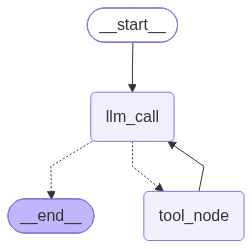

TypeError: BaseTool.invoke() missing 1 required positional argument: 'input'

In [27]:
#Build workflow 
agent_builder = StateGraph(MessageState)

#add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# add edges to connect the nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# complile the agent
agent = agent_builder.compile()

# Show the agent in a visual graph
from IPython.display import display, Image
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()